In [2]:
%pip install xgboost
%pip install pennylane
%pip install pennylane-qiskit

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/8.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.6 MB 5.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.4/8.6 MB 7.1 MB/s eta 0:00:01
   ------------------- -------------------- 4.2/8.6 MB 7.6 MB/s eta 0:00:01
   -------------------------- ------------- 5.8/8.6 MB 7.7 MB/s eta 0:00:01
   ----------------------------------- ---- 7.6/8.6 MB 7.8 MB/s eta 0:00:01
   ---------------------------------------- 8.6/8.6 MB 7.8 MB/s  0:00:01
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.6 MB 8.4 MB/s eta 0:00:01
   -------------- ------------------------- 3.4/9.6 MB 8.4 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.6 MB 8.4 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
iqm-client 34.0.1 requires requests==2.32.3, but you have requests 2.34.2 which is incompatible.


In [ ]:
import pandas as pd

# Wczytanie danych
df = pd.read_csv('AirPassengers.txt')

# Sprawdzenie pierwszych rzędów
print(df)

       Month  Passengers
0    1949-01         112
1    1949-02         118
2    1949-03         132
3    1949-04         129
4    1949-05         121
..       ...         ...
139  1960-08         606
140  1960-09         508
141  1960-10         461
142  1960-11         390
143  1960-12         432

[144 rows x 2 columns]


Tworzenie nowych datasetów - trend spadkowy i boczny

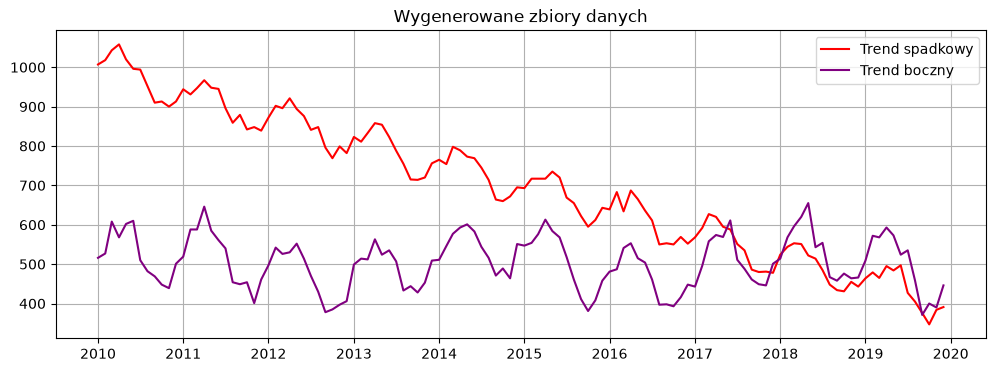

Gotowe! Pliki 'Trend_Spadkowy.txt' i 'Trend_Boczny.txt' zapisane.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ustawienie ziarna losowości dla powtarzalności wyników
np.random.seed(42)

# Oś czasu: 10 lat (120 miesięcy)
dates = pd.date_range(start='2010-01-01', periods=120, freq='MS')
t = np.arange(120)

# ==========================================
# 1. Zbiór z trendem spadkowym
# ==========================================
# Liniowy spadek od 1000 w dół, nałożona sezonowość i szum
trend_down = 1000 - (5 * t)
seasonality_1 = 50 * np.sin(2 * np.pi * t / 12)
noise_1 = np.random.normal(0, 15, 120)
sales_down = trend_down + seasonality_1 + noise_1

df_down = pd.DataFrame({'Month': dates, 'Passengers': sales_down}) # Zostawiam nazwę kolumny 'Passengers' dla wygody
df_down['Passengers'] = df_down['Passengers'].round(0).astype(int)
df_down.to_csv('Trend_Spadkowy.txt', index=False)

# ==========================================
# 2. Zbiór z trendem bocznym (mieszanym)
# ==========================================
# Stabilna baza 500, podwójna cykliczność (12 mies. i 45 mies.) oraz szum
base_level = 500
seasonality_2 = 80 * np.sin(2 * np.pi * t / 12)
long_cycle = 40 * np.sin(2 * np.pi * t / 45)
noise_2 = np.random.normal(0, 20, 120)
sideways = base_level + seasonality_2 + long_cycle + noise_2

df_side = pd.DataFrame({'Month': dates, 'Passengers': sideways})
df_side['Passengers'] = df_side['Passengers'].round(0).astype(int)
df_side.to_csv('Trend_Boczny.txt', index=False)

# Szybki podgląd wygenerowanych danych
plt.figure(figsize=(12, 4))
plt.plot(df_down['Month'], df_down['Passengers'], label='Trend spadkowy', color='red')
plt.plot(df_side['Month'], df_side['Passengers'], label='Trend boczny', color='purple')
plt.title('Wygenerowane zbiory danych')
plt.legend()
plt.grid(True)
plt.show()

print("Gotowe! Pliki 'Trend_Spadkowy.txt' i 'Trend_Boczny.txt' zapisane.")

Aproksymacja Xgboost dla trendu rosnącego, bocznego i spadkowego + porównanie wyników

Błąd RMSE dla Trend Wzrostowy: 17.20


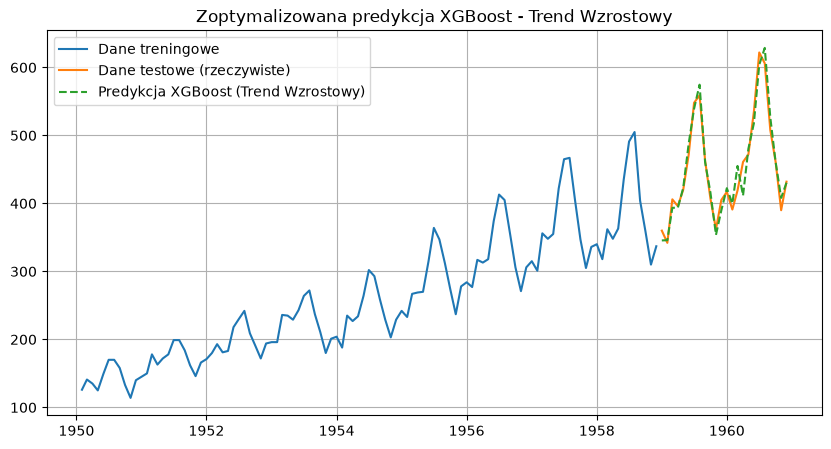

Błąd RMSE dla Trend Spadkowy: 19.68


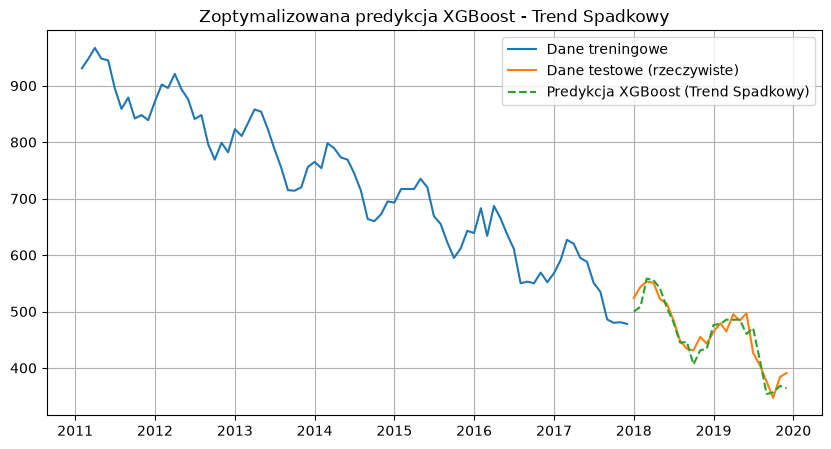

Błąd RMSE dla Trend Boczny (Mieszany): 37.27


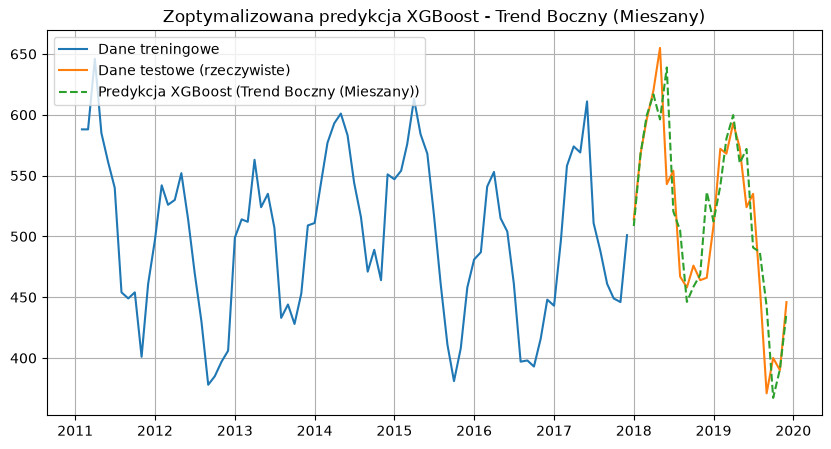

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

def evaluate_xgboost(file_name, trend_name):
    # 1. Wczytanie danych
    df = pd.read_csv(file_name)
    df['Month'] = pd.to_datetime(df['Month'])
    
    # 2. Różnicowanie
    df['Diff'] = df['Passengers'].diff(1)
    
    # 3. Inżynieria cech
    df['Year'] = df['Month'].dt.year
    df['Month_Num'] = df['Month'].dt.month
    df['Lag_1_Diff'] = df['Diff'].shift(1)
    df['Lag_12_Diff'] = df['Diff'].shift(12)
    df = df.dropna().reset_index(drop=True)
    
    # 4. Podział na zbiór treningowy i testowy
    train = df.iloc[:-24]
    test = df.iloc[-24:].copy()
    
    features = ['Year', 'Month_Num', 'Lag_1_Diff', 'Lag_12_Diff']
    target = 'Diff'
    
    X_train, y_train = train[features], train[target]
    X_test, y_test = test[features], test[target]
    
    # 5. Definicja i trenowanie modelu
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # 6. Predykcja i odwrócenie różnicowania
    diff_predictions = model.predict(X_test)
    
    test['Prev_Month_Passengers'] = test['Passengers'].shift(1)
    test.loc[test.index[0], 'Prev_Month_Passengers'] = train.iloc[-1]['Passengers']
    test['Predicted_Passengers'] = test['Prev_Month_Passengers'] + diff_predictions
    
    # 7. Ewaluacja
    rmse = np.sqrt(mean_squared_error(test['Passengers'], test['Predicted_Passengers']))
    print(f"Błąd RMSE dla {trend_name}: {rmse:.2f}")
    
    # 8. Wykres
    plt.figure(figsize=(10, 5))
    plt.plot(train['Month'], train['Passengers'], label='Dane treningowe')
    plt.plot(test['Month'], test['Passengers'], label='Dane testowe (rzeczywiste)')
    plt.plot(test['Month'], test['Predicted_Passengers'], label=f'Predykcja XGBoost ({trend_name})', linestyle='--')
    plt.title(f'Zoptymalizowana predykcja XGBoost - {trend_name}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return rmse

# --- Główna część programu ---
datasets = {
    'AirPassengers.txt': 'Trend Wzrostowy',
    'Trend_Spadkowy.txt': 'Trend Spadkowy',
    'Trend_Boczny.txt': 'Trend Boczny (Mieszany)'
}

results = {}

for file, name in datasets.items():
    results[name] = evaluate_xgboost(file, name)

Model hybrydowy - symulacja Odry 5

In [ ]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

def evaluate_vqc_models(file_name, trend_name, epochs=300, lr=0.01):
    if not os.path.exists(file_name):
        print(f"Brak pliku: {file_name}. Pomijam...")
        return None, None

    # 1. Przygotowanie danych
    df = pd.read_csv(file_name)
    df['Month'] = pd.to_datetime(df['Month'])
    df['Diff'] = df['Passengers'].diff(1)
    
    df['Year'] = df['Month'].dt.year
    df['Month_Num'] = df['Month'].dt.month
    df['Lag_1_Diff'] = df['Diff'].shift(1)
    df['Lag_12_Diff'] = df['Diff'].shift(12)
    df = df.dropna().reset_index(drop=True)
    
    features = ['Year', 'Month_Num', 'Lag_1_Diff', 'Lag_12_Diff']
    target = 'Diff'
    
    X_raw = df[features].values
    y = df[target].values
    
    split_idx = -24
    X_train_raw, y_train = X_raw[:split_idx], y[:split_idx]
    X_test_raw, y_test = X_raw[split_idx:], y[split_idx:]
    
    # Skalowanie [-pi, pi]
    train_min = X_train_raw.min(axis=0)
    train_max = X_train_raw.max(axis=0)
    ptp = train_max - train_min
    ptp[ptp == 0] = 1.0 
    
    X_train_scaled = (X_train_raw - train_min) / ptp * 2 * np.pi - np.pi
    X_test_scaled = (X_test_raw - train_min) / ptp * 2 * np.pi - np.pi
    
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

    # 2. SILNIE SPLĄTANY UKŁAD KWANTOWY (4 KUBITY = 4 CECHY)
    n_qubits = 4
    n_layers = 3
    dev = qml.device("default.qubit", wires=n_qubits)
    
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def vqc_circuit(inputs, weights):
        # Kodowanie bezpośrednie 4 cech na 4 kubity
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
        
        # POPRAWIONA NAZWA SZABLONU: StronglyEntanglingLayers
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
            
        # Pomiary w bazach PauliX, PauliY, PauliZ (4 * 3 = 12 cech)
        return [qml.expval(qml.PauliX(i)) for i in range(n_qubits)] + \
               [qml.expval(qml.PauliY(i)) for i in range(n_qubits)] + \
               [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    weight_shapes = {"weights": qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)}
    
    class QuantumFeatureExtractor(nn.Module):
        def __init__(self):
            super().__init__()
            self.qlayer = qml.qnn.TorchLayer(vqc_circuit, weight_shapes)
            self.head = nn.Sequential(
                nn.Linear(n_qubits * 3, 16),
                nn.SiLU(),
                nn.Linear(16, 1)
            )

        def forward(self, x):
            q_features = self.qlayer(x)
            out = self.head(q_features)
            return out, q_features

    # 3. Trening VQC z Cosine Annealing (300 epok)
    torch.manual_seed(42)
    model_vqc = QuantumFeatureExtractor()
    optimizer = optim.AdamW(model_vqc.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()

    model_vqc.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds, _ = model_vqc(X_train_t)
        loss = criterion(preds, y_train_t)
        loss.backward()
        optimizer.step()
        scheduler.step()

    # Ekstrakcja surowych cech kwantowych
    model_vqc.eval()
    with torch.no_grad():
        _, X_train_vqc = model_vqc(X_train_t)
        _, X_test_vqc = model_vqc(X_test_t)

    X_train_vqc = X_train_vqc.detach().cpu().numpy()
    X_test_vqc = X_test_vqc.detach().cpu().numpy()

    # REDUKCJA SZUMU: PCA cech kwantowych do Top 3 składowych
    pca = PCA(n_components=3, random_state=42)
    X_train_vqc_pca = pca.fit_transform(X_train_vqc)
    X_test_vqc_pca = pca.transform(X_test_vqc)

    # FUZJA CECH (4 klasyczne + 3 kwantowe PCA = 7 cech)
    X_train_hybrid = np.hstack([X_train_raw, X_train_vqc_pca])
    X_test_hybrid = np.hstack([X_test_raw, X_test_vqc_pca])

    # 4. XGBoost z regularyzacją
    xgb_base_params = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.08, 'random_state': 42}
    xgb_hybr_params = {
        'n_estimators': 120,
        'max_depth': 3,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42
    }
    
    # Model Klasyczny
    model_class = xgb.XGBRegressor(**xgb_base_params)
    model_class.fit(X_train_raw, y_train)
    preds_class_diff = model_class.predict(X_test_raw)
    
    # Hybryda VQC + PCA + XGBoost
    model_quant = xgb.XGBRegressor(**xgb_hybr_params)
    model_quant.fit(X_train_hybrid, y_train)
    preds_quant_diff = model_quant.predict(X_test_hybrid)
    
    # 5. Ewaluacja
    prev_values = df['Passengers'].iloc[split_idx-1 : -1].values
    true_values = df['Passengers'].iloc[split_idx:].values
    
    preds_class_abs = prev_values + preds_class_diff
    preds_quant_abs = prev_values + preds_quant_diff
    
    rmse_class = np.sqrt(mean_squared_error(true_values, preds_class_abs))
    rmse_vqc = np.sqrt(mean_squared_error(true_values, preds_quant_abs))
    
    return rmse_class, rmse_vqc

# URUCHOMIENIE TESTÓW
datasets = {
    'AirPassengers.txt': 'Wzrostowy',
    'Trend_Spadkowy.txt': 'Spadkowy',
    'Trend_Boczny.txt': 'Boczny (Mieszany)'
}

print(f"{'Trend':<18} | {'Klasyczny (RMSE)':<18} | {'Zoptymalizowana Hybryda (RMSE)':<30}")
print("-" * 72)

for file, name in datasets.items():
    err_c, err_vqc = evaluate_vqc_models(file, name)
    if err_c is not None:
        print(f"{name:<18} | {err_c:<18.2f} | {err_vqc:<30.2f}")

Trend              | Klasyczny (RMSE)   | Zoptymalizowana Hybryda (RMSE)
------------------------------------------------------------------------
Wzrostowy          | 17.75              | 21.63                         
Spadkowy           | 18.93              | 21.09                         
Boczny (Mieszany)  | 37.17              | 35.45                         


Skrypt realizuje hybrydowy pipeline uczenia maszynowego, łączący klasyczny algorytm **XGBoost** z **kwantowym ekstraktorem cech** (VQC – Variational Quantum Circuit), który może działać zarówno na symulatorze, jak i na prawdziwym polskim komputerze kwantowym **Odra 5 (IQM)**.

Kod składa się z kilku kluczowych bloków logicznych:

### 1. Inicjalizacja i Połączenie z QPU (`get_backend`)

* Funkcja ładuje token autoryzacyjny z pliku środowiskowego (`token.env`) i nawiązuje połączenie z fizycznym lub symulowanym backendem komputera kwantowego Odra 5 za pośrednictwem biblioteki `iqm.qiskit_iqm` oraz `IQMProvider`.

### 2. Przygotowanie danych i inżynieria cech (`evaluate_vqc_models`)

* **Wczytanie i różnicowanie:** Wczytuje plik z danym trendem, a następnie oblicza różnicę miesiąc do miesiąca (`diff(1)`), co pozwala wyeliminować problem rosnącego lub malejącego trendu.
* **Cechy czasowe:** Tworzy zmienne takie jak rok (`Year`), miesiąc (`Month_Num`) oraz opóźnienia (*lag features* względem 1 i 12 miesięcy wstecz).
* **Skalowanie:** Dane wejściowe są skalowane do przedziału $[-\pi, \pi]$, co jest wymagane przez kwantowe bramki rotacyjne.
* **Padding do 5 kubitów:** Ponieważ nasz model ma 4 cechy wejściowe, a Odra 5 posiada 5 kubitów, kod dopisuje piątą kolumnę ze stałymi zerami (`zeros_train`/`zeros_test`), aby dopasować wymiarowość do układu fizycznego.

### 3. Kwantowy Ekstraktor Cech (PyTorch + PennyLane)

* **Obwód kwantowy (`vqc_circuit`):**
* Wykorzystuje kodowanie kątowe (`qml.AngleEmbedding` z rotacjami w osi Y) do zamiany klasycznych liczb na stany kwantowe kubitów.
* Aplikuje warstwę silnie splątującą (`qml.StronglyEntanglingLayers`), która zawiera trenowalne parametry (wagi).
* Wykonuje pomiary wartości oczekiwanych w trzech bazach (`PauliX`, `PauliY`, `PauliZ`) dla każdego z 5 kubitów, co daje łącznie **15 cech kwantowych**.


* **Model sieci (`QuantumFeatureExtractor`):** Łączy warstwę kwantową z małą klasyczną siecią neuronową (warstwa liniowa + aktywacja SiLU) za pomocą `qml.qnn.TorchLayer`.

### 4. Strategia "Sim-to-QPU" (Transfer Learning)

* **Trening na symulatorze:** Ponieważ obliczanie tysięcy gradientów na fizycznym komputerze kwantowym trwałoby bardzo długo i napotykało kolejki, wagi modelu VQC są trenowane **błyskawicznie na symulatorze** (`default.qubit`) przez 300 epok za pomocą optymalizatora `AdamW` i harmonogramu `CosineAnnealingLR`.
* **Przeniesienie na QPU:** Wyuczone wagi są natychmiast ładowane do identycznego modelu spiętego z fizycznym urządzeniem Odra 5 (`dev_qpu`), na którym następuje jednorazowa ekstrakcja cech kwantowych (dla zbioru treningowego i testowego).

### 5. Redukcja wymiarowości i Model Hybrydowy (PCA + XGBoost)

* Ponieważ 15 cech kwantowych to dużo jak na tak mały zbiór, algorytm **PCA** (Analiza Głównych Składowych) redukuje je do 3 najważniejszych składowych.
* Cechy te są łączone z oryginalnymi surowymi danymi czasowymi (`np.hstack`), tworząc hybrydowy zestaw danych.
* Trenowany jest model **XGBoost Regressor**, który przewiduje przyszłe zmiany.

### 6. Ewaluacja i Tabela Wyników

* Otrzymane prognozy różnic są matematycznie odwracane (dodawane do wartości z poprzedniego miesiąca), aby wrócić do oryginalnej skala danych pasażerów.
* Obliczany jest błąd **RMSE** (Root Mean Squared Error) dla trzech wariantów: czystego XGBoosta, hybrydy opartej o symulator oraz hybrydy korzystającej z fizycznego procesora Odra 5 QPU.
* Na samym końcu skrypt generuje podsumowującą, czytelną tabelę porównującą wyniki dla wszystkich trzech analizowanych trendów (Wzrostowego, Spadkowego i Bocznego).

Implementacja połączenia z Odra 5 - 300 epok

In [ ]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# Integracja z IQM i Qiskit
from dotenv import load_dotenv
from iqm.qiskit_iqm import IQMProvider

def get_backend():
    load_dotenv("token.env")
    os.environ["IQM_TOKEN"] = os.getenv("IQM_TOKEN")
    server_url = os.getenv("SERVER")
    provider = IQMProvider(server_url)
    return provider.get_backend()

def evaluate_vqc_models(file_name, trend_name, backend, epochs=300, lr=0.01):
    if not os.path.exists(file_name):
        print(f"Brak pliku: {file_name}. Pomijam...")
        return None, None, None

    # 1. Przygotowanie danych
    df = pd.read_csv(file_name)
    df['Month'] = pd.to_datetime(df['Month'])
    df['Diff'] = df['Passengers'].diff(1)
    
    df['Year'] = df['Month'].dt.year
    df['Month_Num'] = df['Month'].dt.month
    df['Lag_1_Diff'] = df['Diff'].shift(1)
    df['Lag_12_Diff'] = df['Diff'].shift(12)
    df = df.dropna().reset_index(drop=True)
    
    features = ['Year', 'Month_Num', 'Lag_1_Diff', 'Lag_12_Diff']
    target = 'Diff'
    
    X_raw = df[features].values
    y = df[target].values
    
    split_idx = -24
    X_train_raw, y_train = X_raw[:split_idx], y[:split_idx]
    X_test_raw, y_test = X_raw[split_idx:], y[split_idx:]
    
    # Skalowanie [-pi, pi]
    train_min = X_train_raw.min(axis=0)
    train_max = X_train_raw.max(axis=0)
    ptp = train_max - train_min
    ptp[ptp == 0] = 1.0 
    
    X_train_scaled = (X_train_raw - train_min) / ptp * 2 * np.pi - np.pi
    X_test_scaled = (X_test_raw - train_min) / ptp * 2 * np.pi - np.pi
    
    # DOSTOSOWANIE DO 5 KUBITÓW: Dodanie 5. cechy (stałej 0.0)
    zeros_train = np.zeros((X_train_scaled.shape[0], 1))
    zeros_test = np.zeros((X_test_scaled.shape[0], 1))
    X_train_scaled_5q = np.hstack([X_train_scaled, zeros_train])
    X_test_scaled_5q = np.hstack([X_test_scaled, zeros_test])
    
    X_train_t = torch.tensor(X_train_scaled_5q, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    X_test_t = torch.tensor(X_test_scaled_5q, dtype=torch.float32)

    # 2. DEFINICJA URZĄDZEŃ DLA 5 KUBITÓW
    n_qubits = 5
    n_layers = 3
    
    # Urządzenie symulacyjne (szybkie propagowanie wsteczne)
    dev_sim = qml.device("default.qubit", wires=n_qubits)
    # Urządzenie sprzętowe (Odra 5 QPU)
    dev_qpu = qml.device("qiskit.remote", wires=n_qubits, backend=backend, shots=1024)
    
    def vqc_circuit(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
            
        # Pomiary w bazach X, Y, Z dla 5 kubitów (15 cech łącznie)
        return [qml.expval(qml.PauliX(i)) for i in range(n_qubits)] + \
               [qml.expval(qml.PauliY(i)) for i in range(n_qubits)] + \
               [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    qnode_sim = qml.QNode(vqc_circuit, dev_sim, interface="torch", diff_method="backprop")
    qnode_qpu = qml.QNode(vqc_circuit, dev_qpu, interface="torch")

    weight_shapes = {"weights": qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)}
    
    class QuantumFeatureExtractor(nn.Module):
        def __init__(self, qnode):
            super().__init__()
            self.qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)
            self.head = nn.Sequential(
                nn.Linear(n_qubits * 3, 16),
                nn.SiLU(),
                nn.Linear(16, 1)
            )

        def forward(self, x):
            q_features = self.qlayer(x)
            out = self.head(q_features)
            return out, q_features

    # 3. Trening VQC na symulatorze (300 epok)
    torch.manual_seed(42)
    model_sim = QuantumFeatureExtractor(qnode_sim)
    optimizer = optim.AdamW(model_sim.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()

    print(f"\n[{trend_name}] Trenowanie wag VQC na symulatorze...")
    model_sim.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds, _ = model_sim(X_train_t)
        loss = criterion(preds, y_train_t)
        loss.backward()
        optimizer.step()
        scheduler.step()

    # Ekstrakcja cech z symulatora
    model_sim.eval()
    with torch.no_grad():
        _, X_train_vqc_sim = model_sim(X_train_t)
        _, X_test_vqc_sim = model_sim(X_test_t)
    X_train_vqc_sim = X_train_vqc_sim.detach().cpu().numpy()
    X_test_vqc_sim = X_test_vqc_sim.detach().cpu().numpy()

    # 4. Transfer nauki i ekstrakcja cech na QPU Odra 5
    print(f"[{trend_name}] Uruchamianie obwodów i ekstrakcja na fizycznym QPU Odra 5...")
    model_qpu = QuantumFeatureExtractor(qnode_qpu)
    model_qpu.load_state_dict(model_sim.state_dict()) # Przeniesienie wyuczonych wag
    model_qpu.eval()
    
    with torch.no_grad():
        _, X_train_vqc_qpu = model_qpu(X_train_t)
        _, X_test_vqc_qpu = model_qpu(X_test_t)
    X_train_vqc_qpu = X_train_vqc_qpu.detach().cpu().numpy()
    X_test_vqc_qpu = X_test_vqc_qpu.detach().cpu().numpy()

    # 5. Pipeline budowy modeli (PCA + XGBoost)
    xgb_base_params = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.08, 'random_state': 42}
    xgb_hybr_params = {'n_estimators': 120, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42}

    def train_hybrid(X_vqc_train, X_vqc_test):
        pca = PCA(n_components=3, random_state=42)
        vqc_pca_train = pca.fit_transform(X_vqc_train)
        vqc_pca_test = pca.transform(X_vqc_test)
        
        hybrid_train = np.hstack([X_train_raw, vqc_pca_train])
        hybrid_test = np.hstack([X_test_raw, vqc_pca_test])
        
        model = xgb.XGBRegressor(**xgb_hybr_params)
        model.fit(hybrid_train, y_train)
        return model.predict(hybrid_test)

    # Klasyczny XGBoost
    model_class = xgb.XGBRegressor(**xgb_base_params)
    model_class.fit(X_train_raw, y_train)
    preds_class_diff = model_class.predict(X_test_raw)
    
    # Hybrydowe XGBoost
    preds_sim_diff = train_hybrid(X_train_vqc_sim, X_test_vqc_sim)
    preds_qpu_diff = train_hybrid(X_train_vqc_qpu, X_test_vqc_qpu)
    
    # 6. Odwrócenie różnicowania i Ewaluacja RMSE
    prev_values = df['Passengers'].iloc[split_idx-1 : -1].values
    true_values = df['Passengers'].iloc[split_idx:].values
    
    rmse_class = np.sqrt(mean_squared_error(true_values, prev_values + preds_class_diff))
    rmse_sim = np.sqrt(mean_squared_error(true_values, prev_values + preds_sim_diff))
    rmse_qpu = np.sqrt(mean_squared_error(true_values, prev_values + preds_qpu_diff))
    
    return rmse_class, rmse_sim, rmse_qpu

# URUCHOMIENIE TESTÓW
if __name__ == "__main__":
    try:
        odra_backend = get_backend()
        print(f"Połączono z backendem: {odra_backend.name}\n")
        
        datasets = {
            'AirPassengers.txt': 'Wzrostowy',
            'Trend_Spadkowy.txt': 'Spadkowy',
            'Trend_Boczny.txt': 'Boczny (Mieszany)'
        }

        summary_results = []

        for file, name in datasets.items():
            err_c, err_sim, err_qpu = evaluate_vqc_models(file, name, backend=odra_backend)
            if err_c is not None:
                summary_results.append({
                    "Trend": name,
                    "Klasyczny (RMSE)": round(err_c, 2),
                    "Symulator (RMSE)": round(err_sim, 2),
                    "Odra 5 QPU (RMSE)": round(err_qpu, 2)
                })
                
        if summary_results:
            summary_df = pd.DataFrame(summary_results)
            
            print("\n" + "="*70)
            print("         PODSUMOWANIE WYNIKÓW - BŁĘDY RMSE DLA WSZYSTKICH TRENDÓW")
            print("="*70)
            print(summary_df.to_string(index=False))
            print("="*70 + "\n")
            
    except Exception as e:
        print("Błąd konfiguracji IQM: Sprawdź plik token.env i ważność tokenu.")
        print(str(e))

Połączono z backendem: IQMBackend


[Wzrostowy] Trenowanie wag VQC na symulatorze...


c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\pennylane\devices\device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


[Wzrostowy] Uruchamianie obwodów i ekstrakcja na fizycznym QPU Odra 5...


c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\iqm\qiskit_iqm\iqm_provider.py:194: UserWarning: Unknown backend option(s): {'seed_simulator': None}
  warnings.warn(f"Unknown backend option(s): {unknown_options}")
Progress in queue:   0%|          | 0/1 [00:02<?, ?it/s]
c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\pennylane\devices\device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(



[Spadkowy] Trenowanie wag VQC na symulatorze...
[Spadkowy] Uruchamianie obwodów i ekstrakcja na fizycznym QPU Odra 5...


c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\iqm\qiskit_iqm\iqm_provider.py:194: UserWarning: Unknown backend option(s): {'seed_simulator': None}
  warnings.warn(f"Unknown backend option(s): {unknown_options}")
Progress in queue:   0%|          | 0/1 [00:01<?, ?it/s]
c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\pennylane\devices\device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(



[Boczny (Mieszany)] Trenowanie wag VQC na symulatorze...
[Boczny (Mieszany)] Uruchamianie obwodów i ekstrakcja na fizycznym QPU Odra 5...


c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\iqm\qiskit_iqm\iqm_provider.py:194: UserWarning: Unknown backend option(s): {'seed_simulator': None}
  warnings.warn(f"Unknown backend option(s): {unknown_options}")
Progress in queue:   0%|          | 0/1 [00:02<?, ?it/s]



         PODSUMOWANIE WYNIKÓW - BŁĘDY RMSE DLA WSZYSTKICH TRENDÓW
            Trend  Klasyczny (RMSE)  Symulator (RMSE)  Odra 5 QPU (RMSE)
        Wzrostowy             17.75             24.90              18.35
         Spadkowy             18.93             19.26              18.37
Boczny (Mieszany)             37.17             40.09              38.19



Implementacja połączenia z Odra 5 - 50 epok

In [ ]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# Integracja z IQM i Qiskit
from dotenv import load_dotenv
from iqm.qiskit_iqm import IQMProvider

def get_backend():
    load_dotenv("token.env")
    os.environ["IQM_TOKEN"] = os.getenv("IQM_TOKEN")
    server_url = os.getenv("SERVER")
    provider = IQMProvider(server_url)
    return provider.get_backend()

def evaluate_vqc_models(file_name, trend_name, backend, epochs=50, lr=0.01):
    if not os.path.exists(file_name):
        print(f"Brak pliku: {file_name}. Pomijam...")
        return None, None, None

    # 1. Przygotowanie danych
    df = pd.read_csv(file_name)
    df['Month'] = pd.to_datetime(df['Month'])
    df['Diff'] = df['Passengers'].diff(1)
    
    df['Year'] = df['Month'].dt.year
    df['Month_Num'] = df['Month'].dt.month
    df['Lag_1_Diff'] = df['Diff'].shift(1)
    df['Lag_12_Diff'] = df['Diff'].shift(12)
    df = df.dropna().reset_index(drop=True)
    
    features = ['Year', 'Month_Num', 'Lag_1_Diff', 'Lag_12_Diff']
    target = 'Diff'
    
    X_raw = df[features].values
    y = df[target].values
    
    split_idx = -24
    X_train_raw, y_train = X_raw[:split_idx], y[:split_idx]
    X_test_raw, y_test = X_raw[split_idx:], y[split_idx:]
    
    # Skalowanie [-pi, pi]
    train_min = X_train_raw.min(axis=0)
    train_max = X_train_raw.max(axis=0)
    ptp = train_max - train_min
    ptp[ptp == 0] = 1.0 
    
    X_train_scaled = (X_train_raw - train_min) / ptp * 2 * np.pi - np.pi
    X_test_scaled = (X_test_raw - train_min) / ptp * 2 * np.pi - np.pi
    
    # DOSTOSOWANIE DO 5 KUBITÓW: Dodanie 5. cechy (stałej 0.0)
    zeros_train = np.zeros((X_train_scaled.shape[0], 1))
    zeros_test = np.zeros((X_test_scaled.shape[0], 1))
    X_train_scaled_5q = np.hstack([X_train_scaled, zeros_train])
    X_test_scaled_5q = np.hstack([X_test_scaled, zeros_test])
    
    X_train_t = torch.tensor(X_train_scaled_5q, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    X_test_t = torch.tensor(X_test_scaled_5q, dtype=torch.float32)

    # 2. DEFINICJA URZĄDZEŃ DLA 5 KUBITÓW
    n_qubits = 5
    n_layers = 3
    
    # Urządzenie symulacyjne (szybkie propagowanie wsteczne)
    dev_sim = qml.device("default.qubit", wires=n_qubits)
    # Urządzenie sprzętowe (Odra 5 QPU)
    dev_qpu = qml.device("qiskit.remote", wires=n_qubits, backend=backend, shots=1024)
    
    def vqc_circuit(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
            
        # Pomiary w bazach X, Y, Z dla 5 kubitów (15 cech łącznie)
        return [qml.expval(qml.PauliX(i)) for i in range(n_qubits)] + \
               [qml.expval(qml.PauliY(i)) for i in range(n_qubits)] + \
               [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    qnode_sim = qml.QNode(vqc_circuit, dev_sim, interface="torch", diff_method="backprop")
    qnode_qpu = qml.QNode(vqc_circuit, dev_qpu, interface="torch")

    weight_shapes = {"weights": qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)}
    
    class QuantumFeatureExtractor(nn.Module):
        def __init__(self, qnode):
            super().__init__()
            self.qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)
            self.head = nn.Sequential(
                nn.Linear(n_qubits * 3, 16),
                nn.SiLU(),
                nn.Linear(16, 1)
            )

        def forward(self, x):
            q_features = self.qlayer(x)
            out = self.head(q_features)
            return out, q_features

    # 3. Trening VQC na symulatorze (300 epok)
    torch.manual_seed(42)
    model_sim = QuantumFeatureExtractor(qnode_sim)
    optimizer = optim.AdamW(model_sim.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()

    print(f"\n[{trend_name}] Trenowanie wag VQC na symulatorze...")
    model_sim.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds, _ = model_sim(X_train_t)
        loss = criterion(preds, y_train_t)
        loss.backward()
        optimizer.step()
        scheduler.step()

    # Ekstrakcja cech z symulatora
    model_sim.eval()
    with torch.no_grad():
        _, X_train_vqc_sim = model_sim(X_train_t)
        _, X_test_vqc_sim = model_sim(X_test_t)
    X_train_vqc_sim = X_train_vqc_sim.detach().cpu().numpy()
    X_test_vqc_sim = X_test_vqc_sim.detach().cpu().numpy()

    # 4. Transfer nauki i ekstrakcja cech na QPU Odra 5
    print(f"[{trend_name}] Uruchamianie obwodów i ekstrakcja na fizycznym QPU Odra 5...")
    model_qpu = QuantumFeatureExtractor(qnode_qpu)
    model_qpu.load_state_dict(model_sim.state_dict()) # Przeniesienie wyuczonych wag
    model_qpu.eval()
    
    with torch.no_grad():
        _, X_train_vqc_qpu = model_qpu(X_train_t)
        _, X_test_vqc_qpu = model_qpu(X_test_t)
    X_train_vqc_qpu = X_train_vqc_qpu.detach().cpu().numpy()
    X_test_vqc_qpu = X_test_vqc_qpu.detach().cpu().numpy()

    # 5. Pipeline budowy modeli (PCA + XGBoost)
    xgb_base_params = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.08, 'random_state': 42}
    xgb_hybr_params = {'n_estimators': 120, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42}

    def train_hybrid(X_vqc_train, X_vqc_test):
        pca = PCA(n_components=3, random_state=42)
        vqc_pca_train = pca.fit_transform(X_vqc_train)
        vqc_pca_test = pca.transform(X_vqc_test)
        
        hybrid_train = np.hstack([X_train_raw, vqc_pca_train])
        hybrid_test = np.hstack([X_test_raw, vqc_pca_test])
        
        model = xgb.XGBRegressor(**xgb_hybr_params)
        model.fit(hybrid_train, y_train)
        return model.predict(hybrid_test)

    # Klasyczny XGBoost
    model_class = xgb.XGBRegressor(**xgb_base_params)
    model_class.fit(X_train_raw, y_train)
    preds_class_diff = model_class.predict(X_test_raw)
    
    # Hybrydowe XGBoost
    preds_sim_diff = train_hybrid(X_train_vqc_sim, X_test_vqc_sim)
    preds_qpu_diff = train_hybrid(X_train_vqc_qpu, X_test_vqc_qpu)
    
    # 6. Odwrócenie różnicowania i Ewaluacja RMSE
    prev_values = df['Passengers'].iloc[split_idx-1 : -1].values
    true_values = df['Passengers'].iloc[split_idx:].values
    
    rmse_class = np.sqrt(mean_squared_error(true_values, prev_values + preds_class_diff))
    rmse_sim = np.sqrt(mean_squared_error(true_values, prev_values + preds_sim_diff))
    rmse_qpu = np.sqrt(mean_squared_error(true_values, prev_values + preds_qpu_diff))
    
    return rmse_class, rmse_sim, rmse_qpu

# URUCHOMIENIE TESTÓW
if __name__ == "__main__":
    try:
        odra_backend = get_backend()
        print(f"Połączono z backendem: {odra_backend.name}\n")
        
        datasets = {
            'AirPassengers.txt': 'Wzrostowy',
            'Trend_Spadkowy.txt': 'Spadkowy',
            'Trend_Boczny.txt': 'Boczny (Mieszany)'
        }

        summary_results = []

        for file, name in datasets.items():
            err_c, err_sim, err_qpu = evaluate_vqc_models(file, name, backend=odra_backend)
            if err_c is not None:
                summary_results.append({
                    "Trend": name,
                    "Klasyczny (RMSE)": round(err_c, 2),
                    "Symulator (RMSE)": round(err_sim, 2),
                    "Odra 5 QPU (RMSE)": round(err_qpu, 2)
                })
                
        if summary_results:
            summary_df = pd.DataFrame(summary_results)
            
            print("\n" + "="*70)
            print("         PODSUMOWANIE WYNIKÓW - BŁĘDY RMSE DLA WSZYSTKICH TRENDÓW")
            print("="*70)
            print(summary_df.to_string(index=False))
            print("="*70 + "\n")
            
    except Exception as e:
        print("Błąd konfiguracji IQM: Sprawdź plik token.env i ważność tokenu.")
        print(str(e))

c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Połączono z backendem: IQMBackend



c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\pennylane\devices\device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(



[Wzrostowy] Trenowanie wag VQC na symulatorze...
[Wzrostowy] Uruchamianie obwodów i ekstrakcja na fizycznym QPU Odra 5...


c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\iqm\qiskit_iqm\iqm_provider.py:194: UserWarning: Unknown backend option(s): {'seed_simulator': None}
  warnings.warn(f"Unknown backend option(s): {unknown_options}")
Progress in queue:   0%|          | 0/1 [00:02<?, ?it/s]
c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\pennylane\devices\device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(



[Spadkowy] Trenowanie wag VQC na symulatorze...
[Spadkowy] Uruchamianie obwodów i ekstrakcja na fizycznym QPU Odra 5...


c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\iqm\qiskit_iqm\iqm_provider.py:194: UserWarning: Unknown backend option(s): {'seed_simulator': None}
  warnings.warn(f"Unknown backend option(s): {unknown_options}")
Progress in queue:   0%|          | 0/1 [00:02<?, ?it/s]
c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\pennylane\devices\device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(



[Boczny (Mieszany)] Trenowanie wag VQC na symulatorze...
[Boczny (Mieszany)] Uruchamianie obwodów i ekstrakcja na fizycznym QPU Odra 5...


c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\iqm\qiskit_iqm\iqm_provider.py:194: UserWarning: Unknown backend option(s): {'seed_simulator': None}
  warnings.warn(f"Unknown backend option(s): {unknown_options}")
Progress in queue:   0%|          | 0/1 [00:02<?, ?it/s]



         PODSUMOWANIE WYNIKÓW - BŁĘDY RMSE DLA WSZYSTKICH TRENDÓW
            Trend  Klasyczny (RMSE)  Symulator (RMSE)  Odra 5 QPU (RMSE)
        Wzrostowy             17.75             19.62              17.18
         Spadkowy             18.93             20.06              19.21
Boczny (Mieszany)             37.17             37.42              37.17



Implementacja połączenia z Odra 5 - 600 epok

In [ ]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# Integracja z IQM i Qiskit
from dotenv import load_dotenv
from iqm.qiskit_iqm import IQMProvider

def get_backend():
    load_dotenv("token.env")
    os.environ["IQM_TOKEN"] = os.getenv("IQM_TOKEN")
    server_url = os.getenv("SERVER")
    provider = IQMProvider(server_url)
    return provider.get_backend()

def evaluate_vqc_models(file_name, trend_name, backend, epochs=600, lr=0.01):
    if not os.path.exists(file_name):
        print(f"Brak pliku: {file_name}. Pomijam...")
        return None, None, None

    # 1. Przygotowanie danych
    df = pd.read_csv(file_name)
    df['Month'] = pd.to_datetime(df['Month'])
    df['Diff'] = df['Passengers'].diff(1)
    
    df['Year'] = df['Month'].dt.year
    df['Month_Num'] = df['Month'].dt.month
    df['Lag_1_Diff'] = df['Diff'].shift(1)
    df['Lag_12_Diff'] = df['Diff'].shift(12)
    df = df.dropna().reset_index(drop=True)
    
    features = ['Year', 'Month_Num', 'Lag_1_Diff', 'Lag_12_Diff']
    target = 'Diff'
    
    X_raw = df[features].values
    y = df[target].values
    
    split_idx = -24
    X_train_raw, y_train = X_raw[:split_idx], y[:split_idx]
    X_test_raw, y_test = X_raw[split_idx:], y[split_idx:]
    
    # Skalowanie [-pi, pi]
    train_min = X_train_raw.min(axis=0)
    train_max = X_train_raw.max(axis=0)
    ptp = train_max - train_min
    ptp[ptp == 0] = 1.0 
    
    X_train_scaled = (X_train_raw - train_min) / ptp * 2 * np.pi - np.pi
    X_test_scaled = (X_test_raw - train_min) / ptp * 2 * np.pi - np.pi
    
    # DOSTOSOWANIE DO 5 KUBITÓW: Dodanie 5. cechy (stałej 0.0)
    zeros_train = np.zeros((X_train_scaled.shape[0], 1))
    zeros_test = np.zeros((X_test_scaled.shape[0], 1))
    X_train_scaled_5q = np.hstack([X_train_scaled, zeros_train])
    X_test_scaled_5q = np.hstack([X_test_scaled, zeros_test])
    
    X_train_t = torch.tensor(X_train_scaled_5q, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    X_test_t = torch.tensor(X_test_scaled_5q, dtype=torch.float32)

    # 2. DEFINICJA URZĄDZEŃ DLA 5 KUBITÓW
    n_qubits = 5
    n_layers = 3
    
    # Urządzenie symulacyjne (szybkie propagowanie wsteczne)
    dev_sim = qml.device("default.qubit", wires=n_qubits)
    # Urządzenie sprzętowe (Odra 5 QPU)
    dev_qpu = qml.device("qiskit.remote", wires=n_qubits, backend=backend, shots=1024)
    
    def vqc_circuit(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
            
        # Pomiary w bazach X, Y, Z dla 5 kubitów (15 cech łącznie)
        return [qml.expval(qml.PauliX(i)) for i in range(n_qubits)] + \
               [qml.expval(qml.PauliY(i)) for i in range(n_qubits)] + \
               [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    qnode_sim = qml.QNode(vqc_circuit, dev_sim, interface="torch", diff_method="backprop")
    qnode_qpu = qml.QNode(vqc_circuit, dev_qpu, interface="torch")

    weight_shapes = {"weights": qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)}
    
    class QuantumFeatureExtractor(nn.Module):
        def __init__(self, qnode):
            super().__init__()
            self.qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)
            self.head = nn.Sequential(
                nn.Linear(n_qubits * 3, 16),
                nn.SiLU(),
                nn.Linear(16, 1)
            )

        def forward(self, x):
            q_features = self.qlayer(x)
            out = self.head(q_features)
            return out, q_features

    # 3. Trening VQC na symulatorze (300 epok)
    torch.manual_seed(42)
    model_sim = QuantumFeatureExtractor(qnode_sim)
    optimizer = optim.AdamW(model_sim.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()

    print(f"\n[{trend_name}] Trenowanie wag VQC na symulatorze...")
    model_sim.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds, _ = model_sim(X_train_t)
        loss = criterion(preds, y_train_t)
        loss.backward()
        optimizer.step()
        scheduler.step()

    # Ekstrakcja cech z symulatora
    model_sim.eval()
    with torch.no_grad():
        _, X_train_vqc_sim = model_sim(X_train_t)
        _, X_test_vqc_sim = model_sim(X_test_t)
    X_train_vqc_sim = X_train_vqc_sim.detach().cpu().numpy()
    X_test_vqc_sim = X_test_vqc_sim.detach().cpu().numpy()

    # 4. Transfer nauki i ekstrakcja cech na QPU Odra 5
    print(f"[{trend_name}] Uruchamianie obwodów i ekstrakcja na fizycznym QPU Odra 5...")
    model_qpu = QuantumFeatureExtractor(qnode_qpu)
    model_qpu.load_state_dict(model_sim.state_dict()) # Przeniesienie wyuczonych wag
    model_qpu.eval()
    
    with torch.no_grad():
        _, X_train_vqc_qpu = model_qpu(X_train_t)
        _, X_test_vqc_qpu = model_qpu(X_test_t)
    X_train_vqc_qpu = X_train_vqc_qpu.detach().cpu().numpy()
    X_test_vqc_qpu = X_test_vqc_qpu.detach().cpu().numpy()

    # 5. Pipeline budowy modeli (PCA + XGBoost)
    xgb_base_params = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.08, 'random_state': 42}
    xgb_hybr_params = {'n_estimators': 120, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42}

    def train_hybrid(X_vqc_train, X_vqc_test):
        pca = PCA(n_components=3, random_state=42)
        vqc_pca_train = pca.fit_transform(X_vqc_train)
        vqc_pca_test = pca.transform(X_vqc_test)
        
        hybrid_train = np.hstack([X_train_raw, vqc_pca_train])
        hybrid_test = np.hstack([X_test_raw, vqc_pca_test])
        
        model = xgb.XGBRegressor(**xgb_hybr_params)
        model.fit(hybrid_train, y_train)
        return model.predict(hybrid_test)

    # Klasyczny XGBoost
    model_class = xgb.XGBRegressor(**xgb_base_params)
    model_class.fit(X_train_raw, y_train)
    preds_class_diff = model_class.predict(X_test_raw)
    
    # Hybrydowe XGBoost
    preds_sim_diff = train_hybrid(X_train_vqc_sim, X_test_vqc_sim)
    preds_qpu_diff = train_hybrid(X_train_vqc_qpu, X_test_vqc_qpu)
    
    # 6. Odwrócenie różnicowania i Ewaluacja RMSE
    prev_values = df['Passengers'].iloc[split_idx-1 : -1].values
    true_values = df['Passengers'].iloc[split_idx:].values
    
    rmse_class = np.sqrt(mean_squared_error(true_values, prev_values + preds_class_diff))
    rmse_sim = np.sqrt(mean_squared_error(true_values, prev_values + preds_sim_diff))
    rmse_qpu = np.sqrt(mean_squared_error(true_values, prev_values + preds_qpu_diff))
    
    return rmse_class, rmse_sim, rmse_qpu

# URUCHOMIENIE TESTÓW
if __name__ == "__main__":
    try:
        odra_backend = get_backend()
        print(f"Połączono z backendem: {odra_backend.name}\n")
        
        datasets = {
            'AirPassengers.txt': 'Wzrostowy',
            'Trend_Spadkowy.txt': 'Spadkowy',
            'Trend_Boczny.txt': 'Boczny (Mieszany)'
        }

        summary_results = []

        for file, name in datasets.items():
            err_c, err_sim, err_qpu = evaluate_vqc_models(file, name, backend=odra_backend)
            if err_c is not None:
                summary_results.append({
                    "Trend": name,
                    "Klasyczny (RMSE)": round(err_c, 2),
                    "Symulator (RMSE)": round(err_sim, 2),
                    "Odra 5 QPU (RMSE)": round(err_qpu, 2)
                })
                
        if summary_results:
            summary_df = pd.DataFrame(summary_results)
            
            print("\n" + "="*70)
            print("         PODSUMOWANIE WYNIKÓW - BŁĘDY RMSE DLA WSZYSTKICH TRENDÓW")
            print("="*70)
            print(summary_df.to_string(index=False))
            print("="*70 + "\n")
            
    except Exception as e:
        print("Błąd konfiguracji IQM: Sprawdź plik token.env i ważność tokenu.")
        print(str(e))

c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Połączono z backendem: IQMBackend



c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\pennylane\devices\device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(



[Wzrostowy] Trenowanie wag VQC na symulatorze...
[Wzrostowy] Uruchamianie obwodów i ekstrakcja na fizycznym QPU Odra 5...


c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\iqm\qiskit_iqm\iqm_provider.py:194: UserWarning: Unknown backend option(s): {'seed_simulator': None}
  warnings.warn(f"Unknown backend option(s): {unknown_options}")
Progress in queue:   0%|          | 0/1 [00:02<?, ?it/s]
c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\pennylane\devices\device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(



[Spadkowy] Trenowanie wag VQC na symulatorze...
[Spadkowy] Uruchamianie obwodów i ekstrakcja na fizycznym QPU Odra 5...


c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\iqm\qiskit_iqm\iqm_provider.py:194: UserWarning: Unknown backend option(s): {'seed_simulator': None}
  warnings.warn(f"Unknown backend option(s): {unknown_options}")
Progress in queue:   0%|          | 0/1 [00:02<?, ?it/s]
c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\pennylane\devices\device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(



[Boczny (Mieszany)] Trenowanie wag VQC na symulatorze...
[Boczny (Mieszany)] Uruchamianie obwodów i ekstrakcja na fizycznym QPU Odra 5...


c:\Users\Grzegorz\.conda\envs\qml\Lib\site-packages\iqm\qiskit_iqm\iqm_provider.py:194: UserWarning: Unknown backend option(s): {'seed_simulator': None}
  warnings.warn(f"Unknown backend option(s): {unknown_options}")
Progress in queue:   0%|          | 0/1 [00:02<?, ?it/s]



         PODSUMOWANIE WYNIKÓW - BŁĘDY RMSE DLA WSZYSTKICH TRENDÓW
            Trend  Klasyczny (RMSE)  Symulator (RMSE)  Odra 5 QPU (RMSE)
        Wzrostowy             17.75             18.10              19.33
         Spadkowy             18.93             20.11              17.57
Boczny (Mieszany)             37.17             34.95              40.50

